## Trying to get more accuracy by using diffrent parmas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from qiskit.circuit.library import (
    zz_feature_map,
    real_amplitudes
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.optimizers import SPSA
from qiskit_machine_learning.utils import algorithm_globals

In [2]:
algorithm_globals.random_seed = 42
np.random.seed(42)

In [3]:
features , labels = make_moons(
    n_samples=40,
    noise=0.15,
    random_state=42
)

In [4]:
scaler = MinMaxScaler()

features = scaler.fit_transform(features)

In [5]:
print(features.shape)
print(labels.shape)

(40, 2)
(40,)


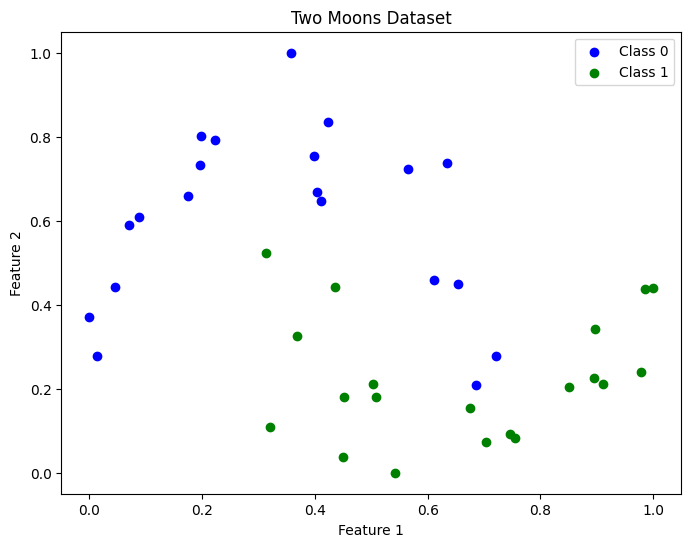

In [6]:
def plot_dataset():
    plt.figure(figsize=(8,6))

    plt.scatter(
        features[labels == 0, 0],
        features[labels == 0, 1],
        color="blue",
        label="Class 0"
    )

    plt.scatter(
        features[labels == 1, 0],
        features[labels == 1, 1],
        color="green",
        label="Class 1"
    )

    plt.title("Two Moons Dataset")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()
    plt.show()

plot_dataset()

In [7]:
train_features , test_features , train_labels , test_lables = train_test_split(
    features , labels , test_size=0.2 , random_state=42
)

In [8]:
encoder = OneHotEncoder(sparse_output=False)

train_labels = encoder.fit_transform(
    train_labels.reshape(-1 , 1)
)

test_lables = encoder.transform(
    test_lables.reshape(-1 , 1)
)

In [9]:
print(train_labels.shape)
print(test_lables.shape)

(32, 2)
(8, 2)


In [10]:
service = QiskitRuntimeService()
print(service.backends())

qiskit_runtime_service.__init__:WARNING:2026-05-27 17:50:51,187: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-27 17:50:51,188: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_fez')>]


In [11]:
least_busy_backend = service.least_busy(
    simulator=False,
    operational=True,
    min_num_qubits=2
)

qiskit_runtime_service.backends:WARNING:2026-05-27 17:50:57,845: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-27 17:51:01,017: Using instance: open-instance, plan: open


In [12]:
backend = least_busy_backend

In [13]:
pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

In [14]:
sampler = Sampler(
    mode=backend,
    options={
        "default_shots": 4096
    }
)

In [15]:
feature_map = zz_feature_map(
    feature_dimension=2,
    reps=2
)

In [16]:
ansatz = real_amplitudes(
    num_qubits=2,
    reps=2
)

In [17]:
optimizer = SPSA(
    maxiter=25
)

In [20]:
objective_values = []

def callback_graph(_, objective_value):
    clear_output(wait=True)
    objective_values.append(objective_value)

    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")

    stage1_len = np.min((len(objective_values), 25))
    stage1_x = np.linspace(1, stage1_len, stage1_len)
    stage1_y = objective_values[:stage1_len]

    plt.plot(stage1_x, stage1_y, color="orange")
    plt.show()

In [21]:
vqc = VQC(
    sampler=sampler,
    ansatz=ansatz,
    feature_map=feature_map,
    optimizer=optimizer,
    callback=callback_graph,
    pass_manager=pass_manager
)

In [22]:
vqc.fit(train_features ,train_labels)

KeyboardInterrupt: 